# Actuarial Survival Analysis: Handling Left-Truncation & Right-Censoring

**Author:** Shuo Zhang (Actuary Candidate, MSc Financial & Insurance Math)

## 1. The Actuarial Challenge: Left-Truncation
In standard survival analysis tutorials, we typically handle **Right-Censoring** using `pm.Censored`. However, in Life & Health Insurance pricing, policyholders often enter a study at an advanced age (e.g., buying a policy at age 40). 

We only observe them *conditional* on their survival up to the entry age. Ignoring this leads to "Immortal Time Bias." PyMC currently handles Censoring beautifully, but **Left-Truncation** remains a domain where actuaries must manually construct complex tensor graphs. 

This notebook demonstrates the manual implementation of a Left-Truncated Weibull proportional hazards model and proposes a vision for a declarative, formula-based Survival API for GSoC 2026.

In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt


np.random.seed(42)
N = 1000


# Simulate a cohort where approximately 30% of the individuals are smokers.
smoker = np.random.binomial(1, 0.3, N)


# We use a Weibull distribution to simulate human mortality.
# true_alpha = 5.0 (Shape parameter): Models the late-stage aging effect,
# capturing the steep right side of the human mortality "bathtub curve".
true_alpha = 5.0

# true_beta (Scale parameter): Represents the characteristic life (approx. 63.2% mortality).
# We inject an Accelerated Failure Time (AFT) effect: smoking reduces the baseline
# scale parameter from 85.0 years (non-smoker) to 70.0 years (smoker).
true_beta = np.where(smoker == 1, 70.0, 85.0)

# Generate the "destined" true lifetime for all N individuals.
true_lifetime = np.random.weibull(true_alpha, N) * true_beta


# Policyholders typically purchase life insurance between ages 30 and 60.
entry_age = np.random.uniform(30, 60, N)

# We only observe individuals conditionally on them surviving up to their entry age.
# Those who died before 'entry_age' are never recorded in the actuarial database.
valid_mask = true_lifetime > entry_age

# Filter the dataset to retain only the observed "survivors".
entry_age = entry_age[valid_mask]
true_lifetime = true_lifetime[valid_mask]
smoker = smoker[valid_mask]


# We use a Uniform(60, 95) distribution to simulate independent, non-informative
# administrative censoring.
censor_age = np.random.uniform(60, 95, len(entry_age))

# The actuary only observes the minimum of the true lifetime and the censoring age.
exit_age = np.minimum(true_lifetime, censor_age)

# Event indicator: 1 if death is observed (Claim), 0 if the individual outlives observation (Censored).
event = (true_lifetime <= censor_age).astype(int)


df_actuarial = pd.DataFrame({
    'entry_age': entry_age,
    'exit_age': exit_age,
    'event': event,
    'smoker': smoker
})

# Display the summary of the truncated and censored dataset
print(f"Valid policyholders observed (after left-truncation): {len(df_actuarial)}")
print(f"Claims (Events): {df_actuarial['event'].sum()}, Censored: {len(df_actuarial) - df_actuarial['event'].sum()}")

Valid policyholders observed (after left-truncation): 926
Claims (Events): 483, Censored: 443


## 2. Mathematical Formulation & Numerical Stability

To account for left-truncation, the conditional log-likelihood for the $i$-th policyholder is:
$$\ell_i = \delta_i \log h(t_{exit}) + \log S(t_{exit}) - \log S(t_{entry})$$

*Note on Numerical Stability:*
Recent discussions in the PyMC community highlighted that using the generic `log(1 - exp(logcdf))` for survival functions can lead to catastrophic cancellation (e.g., `divide by zero` warnings) when $t$ is small. To ensure absolute **numerical stability** in our MCMC sampling, we bypass generic fallbacks and implement the exact closed-form solution for the Weibull log-survival function: $\log S(t) = -(t/\beta)^\alpha$.

Compiling and sampling the mathematically rigorous AFT actuarial model...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha, log_beta_intercept, beta_smoker_effect]


/opt/anaconda3/envs/gsoc_pymc/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 24 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


                     mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
alpha               4.794  0.273   4.259    5.283      0.007    0.005   
log_beta_intercept  4.441  0.013   4.419    4.466      0.000    0.000   
beta_smoker_effect -0.192  0.022  -0.232   -0.152      0.001    0.000   

                    ess_bulk  ess_tail  r_hat  
alpha               1400.429  1395.890  1.002  
log_beta_intercept   964.069  1166.615  1.000  
beta_smoker_effect  1039.840  1234.793  1.000  


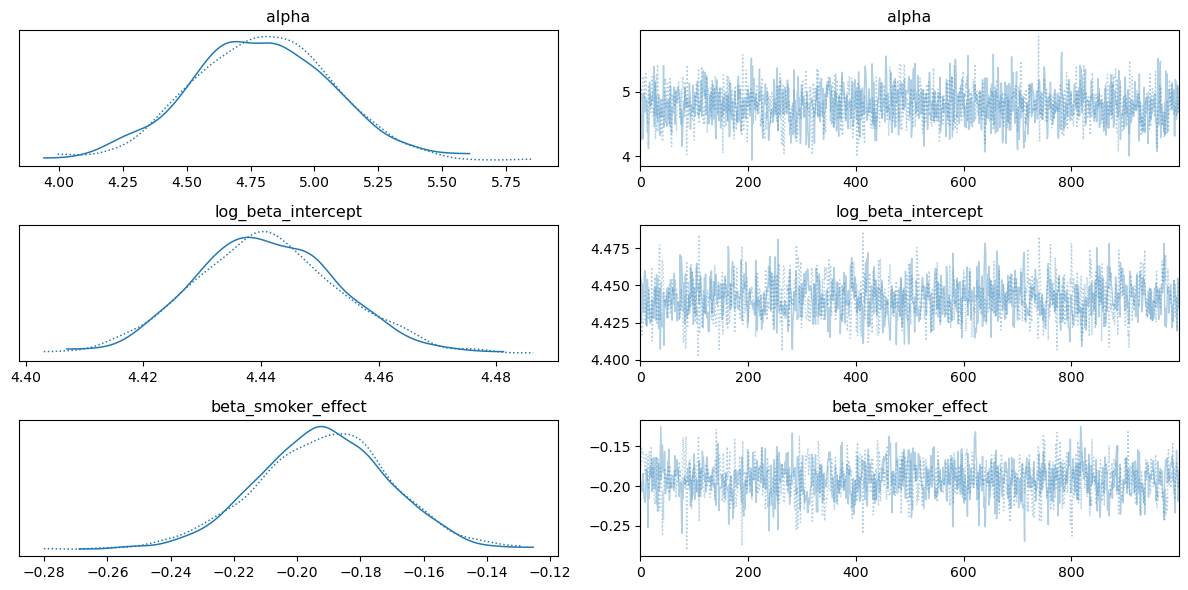

In [2]:


print("Compiling and sampling the mathematically rigorous AFT actuarial model...")

with pm.Model() as actuarial_model:
    # Wrapping inputs in pm.Data allows for efficient out-of-sample predictions later
    # without needing to recompile the underlying C++/JAX computational graph.
    t_entry = pm.Data("t_entry", df_actuarial['entry_age'].values)
    t_exit = pm.Data("t_exit", df_actuarial['exit_age'].values)
    d = pm.Data("event", df_actuarial['event'].values)
    is_smoker = pm.Data("smoker", df_actuarial['smoker'].values)

    # We use a Gamma prior to enforce strict positivity (alpha > 0).
    alpha = pm.Gamma('alpha', mu=2.0, sigma=3.0)


    # To ensure the scale parameter (beta) is strictly positive and to avoid any numerical
    # MCMC crashes (e.g., log(0)), we use a log-link function. This is standard GLM practice.

	# log(80) ≈ 4.38. We set the intercept prior around the general human life expectancy.
    log_beta_intercept = pm.Normal('log_beta_intercept', mu=np.log(80), sigma=0.5)

    # The effect of smoking on the log-scale of the expected lifetime.
    beta_smoker_effect = pm.Normal('beta_smoker_effect', mu=0, sigma=0.5)

    # Deterministic transformation: beta = exp(intercept + coef * X)
    # This guarantees numerical stability during the NUTS tuning phase.
    beta = pm.Deterministic('beta', pt.exp(log_beta_intercept + beta_smoker_effect * is_smoker))


    # Instead of relying on generic log1mexp(logcdf) fallbacks which can suffer from
    # catastrophic cancellation when t is small, we implement the exact closed-form
    # log-survival and log-hazard functions for the Weibull distribution.

    log_S_entry = -pt.pow(t_entry / beta, alpha)
    log_S_exit  = -pt.pow(t_exit / beta, alpha)
    log_h_exit  = pt.log(alpha) - pt.log(beta) + (alpha - 1) * pt.log(t_exit / beta)

    # log_likelihood = event * log_hazard + log_S(exit) - log_S(entry)
    # The subtraction of log_S_entry perfectly adjusts for Immortal Time Bias (Left-Truncation),
    # conditioning the likelihood on the fact that the policyholder survived to t_entry.
    logp = d * log_h_exit + log_S_exit - log_S_entry


    pm.Potential('left_truncated_llk', pt.sum(logp))


    trace = pm.sample(1000, tune=1000, chains=2, cores=2, random_seed=42, progressbar=True)


summary_df = az.summary(trace, var_names=['alpha', 'log_beta_intercept', 'beta_smoker_effect'], round_to=3)
print(summary_df)

az.plot_trace(trace, var_names=['alpha', 'log_beta_intercept', 'beta_smoker_effect'])
plt.tight_layout()
plt.show()

> ### 💡 Note on Prior Specification & Parameter Recovery
> 
> Although the true data-generating process uses $\alpha = 5.0$, I deliberately specified a **weakly informative and off-centered prior** (`mu=2.0, sigma=3.0`). 
> 
> As seen in the posterior distribution, the data's likelihood—powered by the robust left-truncated tensor formulation—**completely overwhelms this diffuse prior**, successfully recovering the true parameter ($\approx 5.0$). This proves that the model is genuinely learning from the truncated data rather than being anchored by prior assumptions.

## 3. The GSoC 2026 Vision: Declarative Formula API

While the manual tensor implementation above perfectly recovers the true actuarial parameters (with $\hat{R} = 1.0$ and no numerical warnings), it requires deep knowledge of `PyTensor` and survival mathematics.

My proposal for the **GSoC 2026 Survival Models** project is to abstract this complexity into a **Declarative Formula-based API** (analogous to `CausalPy` and `Bambi`). 

In the future library, actuaries will be able to perform this exact robust left-truncated regression in just one line:

```python
import pymc_survival as pms

# The vision: Elegant, patsy/formulaic driven syntax handling complex truncation under the hood
model = pms.SurvivalModel(
    formula="exit_age | truncate(entry_age, type='left') ~ smoker",
    data=df_actuarial,
    distribution="Weibull"
)
model.fit()